# Python Notebook 1
## Data Understanding, Cleaning and Preparation
**Author:** Sanidu Harsha  
**Module:** 5DATA002W.2 Machine Learning & Data Mining  
**Case Study A:** Predicting Clients’ Loan Approval Status  
**Case Study B Preparation:** Maximum Loan Amount dataset preparation

> This notebook contains only data understanding, cleaning, and preparation tasks for Notebook 1.

### Reused / adapted from:
Coursework Code Reuse Session 1 and seminar materials for data understanding and preparation.

In [2]:
# Import the required libraries for data handling and visualisation.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots appear inside the notebook.
%matplotlib inline

### Load the dataset
Upload the CSV file to Colab, then read it into a pandas DataFrame.


In [3]:
# Import the upload helper for Google Colab.
from google.colab import files

# Upload the dataset file from the local computer.
uploaded = files.upload()

Saving loan_approval_data.csv to loan_approval_data.csv


In [4]:
# Read the uploaded CSV file into a DataFrame.
df = pd.read_csv("loan_approval_data.csv")

# Display the first five rows of the dataset.
df.head()

,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


### Initial data understanding  
This section shows the structure, columns, descriptive statistics, and missing values.

In [5]:
# Display the column names to confirm the exact field names.
df.columns.tolist()

['id',
 'age',
 'income',
 'home_ownership',
 'emplyment_length',
 'loan_intent',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'payment_default_on_file',
 'credit_history_length',
 'loan_approval_status',
 'max_allowed_loan']

In [6]:
# Display the shape of the dataset.
df.shape

(58645, 13)

In [7]:
# Display dataset information such as data types and non-null counts.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  object 
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  object 
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  object 
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-null  int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 5.8+ MB


In [8]:
# Display descriptive statistics for numerical variables.
df.describe()

,id,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan
count,58645.000000,58639.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000,58645.000000,5.864500e+04
mean,29322.000000,27.550913,6.404617e+04,4.703487,9217.556518,10.677526,0.159238,5.813556,0.142382,6.975472e+04
std,16929.497605,6.033217,3.793111e+04,4.004982,5563.807384,3.036034,0.091692,4.029196,0.349445,6.175091e+04
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000,0.000000,-2.426900e+06
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000,3.800300e+04
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000,6.239200e+04
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000,9.271600e+04
max,58644.000000,123.000000,1.900000e+06,150.000000,35000.000000,23.220000,0.830000,30.000000,1.000000,2.638778e+06


In [9]:
# Display the number of missing values in each column before cleaning.
df.isnull().sum()

,0
id,0
age,6
income,0
home_ownership,0
emplyment_length,0
loan_intent,0
loan_amount,0
loan_interest_rate,11
loan_income_ratio,0
payment_default_on_file,5


In [10]:
# Create a copy of the original dataset before applying cleaning steps.
df_before_cleaning = df.copy()

In [11]:
# Display descriptive statistics for categorical variables.
df.describe(include="object")

,home_ownership,loan_intent,payment_default_on_file
count,58645,58645,58640
unique,4,6,2
top,RENT,EDUCATION,N
freq,30594,12271,49940


### Task 2 evidence  
Take screenshots of the outputs from:
- `df.describe()`
- `df.info()`
- target variable distribution (`value_counts()` and/or count plot)

Paste screenshots of **outputs only** into the report.

In [12]:
# Display the distribution of the target variable.
df["loan_approval_status"].value_counts()

,count
loan_approval_status,
0,50295
1,8350


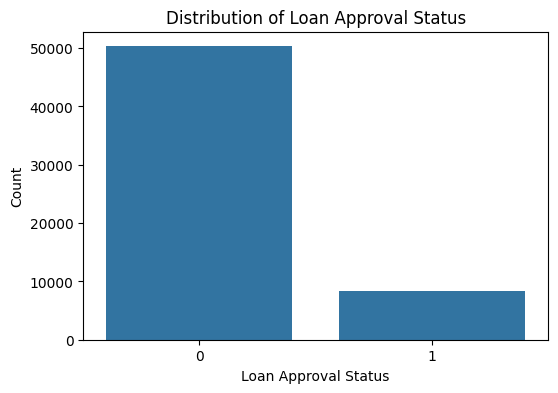

In [13]:
# Plot the distribution of the target variable.
plt.figure(figsize=(6, 4))
sns.countplot(x="loan_approval_status", data=df)
plt.title("Distribution of Loan Approval Status")
plt.xlabel("Loan Approval Status")
plt.ylabel("Count")
plt.show()

### Task 3: Identify issues before cleaning  
This section shows the main issues found before fixing the data.

In [14]:
# Display missing values before cleaning as evidence for Task 3.
df_before_cleaning.isnull().sum()

,0
id,0
age,6
income,0
home_ownership,0
emplyment_length,0
loan_intent,0
loan_amount,0
loan_interest_rate,11
loan_income_ratio,0
payment_default_on_file,5


In [15]:
# Remove the ID column if it exists because it has no predictive value.
df = df.drop(columns=["id"], errors="ignore")

# Display the updated column names after removing the ID column.
df.columns.tolist()

['age',
 'income',
 'home_ownership',
 'emplyment_length',
 'loan_intent',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'payment_default_on_file',
 'credit_history_length',
 'loan_approval_status',
 'max_allowed_loan']

### Handle missing values  
- Numerical columns are filled using the mean.  
- Categorical columns are filled using the mode.

In [16]:
# Fill missing values in the age column using the mean.
if "age" in df.columns:
    df["age"] = df["age"].fillna(df["age"].mean())

# Fill missing values in the loan_interest_rate column using the mean.
if "loan_interest_rate" in df.columns:
    df["loan_interest_rate"] = df["loan_interest_rate"].fillna(df["loan_interest_rate"].mean())

In [17]:
# Find likely payment/default column names to avoid KeyError issues.
[col for col in df.columns if "payment" in col.lower() or "default" in col.lower()]

['payment_default_on_file']

In [18]:
# Fill missing values in the payment default column using the mode.
if "payment_default_on_file" in df.columns:
    df["payment_default_on_file"] = df["payment_default_on_file"].fillna(df["payment_default_on_file"].mode()[0])

In [19]:
# Confirm that missing values have been handled after cleaning.
df.isnull().sum()

,0
age,0
income,0
home_ownership,0
emplyment_length,0
loan_intent,0
loan_amount,0
loan_interest_rate,0
loan_income_ratio,0
payment_default_on_file,0
credit_history_length,0


### Optional issue checks  
These checks help identify duplicated rows and unrealistic values.

In [20]:
# Display the number of duplicated rows in the dataset.
df.duplicated().sum()

np.int64(0)

In [21]:
df.dtypes

,0
age,float64
income,int64
home_ownership,object
emplyment_length,int64
loan_intent,object
loan_amount,int64
loan_interest_rate,float64
loan_income_ratio,float64
payment_default_on_file,object
credit_history_length,int64


In [22]:
df = pd.get_dummies(df, drop_first=True)
df.dtypes

,0
age,float64
income,int64
emplyment_length,int64
loan_amount,int64
loan_interest_rate,float64
loan_income_ratio,float64
credit_history_length,int64
loan_approval_status,int64
max_allowed_loan,int64
home_ownership_OTHER,bool


In [23]:
# Display minimum values for all numerical columns to check for unrealistic values.
df.select_dtypes(include=["int64", "float64"]).min()

,0
age,20.00
income,4200.00
emplyment_length,0.00
loan_amount,500.00
loan_interest_rate,-11.14
loan_income_ratio,0.00
credit_history_length,2.00
loan_approval_status,0.00
max_allowed_loan,-2426900.00


In [24]:
# Display maximum values for all numerical columns to inspect the spread of values.
df.select_dtypes(include=["int64", "float64"]).max()

,0
age,123.00
income,1900000.00
emplyment_length,150.00
loan_amount,35000.00
loan_interest_rate,23.22
loan_income_ratio,0.83
credit_history_length,30.00
loan_approval_status,1.00
max_allowed_loan,2638778.00


### Categorical variable review  
This section shows the categories present in the categorical variables before encoding.

In [25]:
# Display unique values for home ownership.
if "home_ownership" in df.columns:
    print("home_ownership:", df["home_ownership"].unique())

In [26]:
# Display unique values for loan intent.
if "loan_intent" in df.columns:
    print("loan_intent:", df["loan_intent"].unique())

In [27]:
# Display unique values for the payment default column.
if "payment_default_on_file" in df.columns:
    print("payment_default_on_file:", df["payment_default_on_file"].unique())

### Encode categorical variables for machine learning preparation  
This converts text categories into numerical dummy variables.

In [28]:
# Create a prepared version of the cleaned dataset for later modelling.
df_prepared = df.copy()

# Convert categorical variables into dummy variables.
df_prepared = pd.get_dummies(df_prepared, drop_first=True)

# Display the first five rows of the prepared dataset.
df_prepared.head()

,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_Y
0,21.0,12000,0,15000,6.99,0.12,4,0,-2426900,False,True,False,True,False,False,False,False,False
1,21.0,13200,2,25000,16.77,0.19,3,0,-111739,False,True,False,True,False,False,False,False,True
2,23.0,9600,5,30000,12.42,0.31,3,0,-89000,False,False,True,False,False,True,False,False,False
3,40.0,182004,3,35000,8.00,0.19,11,0,35000,False,False,True,True,False,False,False,False,False
4,40.0,90000,3,35000,12.42,0.39,14,0,35000,False,False,False,False,True,False,False,False,False


In [29]:
# Display the shape of the prepared dataset after encoding.
df_prepared.shape

(58645, 18)

In [30]:
# Display the prepared dataset column names after encoding.
df_prepared.columns.tolist()

['age',
 'income',
 'emplyment_length',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'credit_history_length',
 'loan_approval_status',
 'max_allowed_loan',
 'home_ownership_OTHER',
 'home_ownership_OWN',
 'home_ownership_RENT',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'payment_default_on_file_Y']

### Create the two prepared subsets required by the coursework  
- Classification subset for Loan Approval Status  
- Regression subset for Maximum Allowed Loan

In [31]:
# Create the classification subset for loan approval modelling.
classification_df = df_prepared.copy()

# Display the shape of the classification dataset.
classification_df.shape

(58645, 18)

In [32]:
# Create the regression subset using only approved loans if the target column exists.
# Adjust the filter below if your coding of approval/rejection is reversed.
if "loan_approval_status" in df.columns:
    regression_source_df = df[df["loan_approval_status"] == 0].copy()
else:
    regression_source_df = df.copy()

# Display the shape of the source dataset for regression.
regression_source_df.shape

(50295, 18)

In [33]:
# Check the target variable in the regression source dataset.
if "max_allowed_loan" in regression_source_df.columns:
    regression_source_df["max_allowed_loan"].describe()

In [34]:
# Prepare the regression dataset by removing the classification target and encoding categorical variables.
regression_df = regression_source_df.copy()
regression_df = regression_df.drop(columns=["loan_approval_status"], errors="ignore")
regression_df = pd.get_dummies(regression_df, drop_first=True)

# Display the shape of the regression dataset.
regression_df.shape

(50295, 17)

In [38]:
print(regression_df.shape)
print(regression_df.columns)

(50295, 17)
Index(['age', 'income', 'emplyment_length', 'loan_amount',
       'loan_interest_rate', 'loan_income_ratio', 'credit_history_length',
       'max_allowed_loan', 'home_ownership_OTHER', 'home_ownership_OWN',
       'home_ownership_RENT', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'payment_default_on_file_Y'],
      dtype='object')


In [ ]:
# Display the first five rows of the regression dataset.
regression_df.head()

,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,max_allowed_loan,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_Y
0,21.0,12000,0,15000,6.99,0.12,4,-2426900,False,True,False,True,False,False,False,False,False
1,21.0,13200,2,25000,16.77,0.19,3,-111739,False,True,False,True,False,False,False,False,True
2,23.0,9600,5,30000,12.42,0.31,3,-89000,False,False,True,False,False,True,False,False,False
3,40.0,182004,3,35000,8.00,0.19,11,35000,False,False,True,True,False,False,False,False,False
4,40.0,90000,3,35000,12.42,0.39,14,35000,False,False,False,False,True,False,False,False,False


### Save cleaned datasets  
These files can be reused later in Notebook 2 and Notebook 3.

In [ ]:
# Save the cleaned classification dataset to a CSV file.
classification_df.to_csv("classification_dataset_cleaned.csv", index=False)

# Save the cleaned regression dataset to a CSV file.
regression_df.to_csv("regression_dataset_cleaned.csv", index=False)

In [ ]:
# Download the cleaned classification dataset.
files.download("classification_dataset_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Download the cleaned regression dataset.
files.download("regression_dataset_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Summary  
This notebook completed:
- Dataset loading  
- Data structure inspection  
- Descriptive statistics  
- Target distribution  
- Missing value handling  
- Categorical encoding  
- Creation of classification and regression prepared datasets